# Первая модель: определение уровня английского текста по шкале CEFR

## Введение

В этой части проекта мы создаём модель машинного обучения, которая определяет уровень сложности английского текста по общеевропейской шкале CEFR.

CEFR включает шесть уровней владения языком:

- **A1** — начальный уровень;
- **A2** — элементарный уровень;
- **B1** — средний уровень;
- **B2** — уровень выше среднего;
- **C1** — продвинутый уровень;
- **C2** — уровень свободного владения языком.

Наша задача состоит в том, чтобы по входному английскому тексту автоматически предсказать, к какому уровню CEFR он относится. Такая модель может быть полезна для образовательных платформ, подбора учебных материалов, анализа сложности текстов и персонализации обучения.

---

## Данные

Для обучения первой модели был использован готовый датасет с Kaggle: **cefr_leveled_texts.csv**.

В датасете содержатся английские тексты, каждому из которых заранее присвоен уровень CEFR. Основные поля датасета:

- **text** — исходный английский текст;
- **label** — уровень CEFR, к которому относится
Перед обучением модели мы загрузили данные с помощью библиотеки `pandas` и провели первичный анализ датасета. Были проверены названия колонок, общее количество текстов, а также распределение текстов по уровням CEFR.

Для визуального анализа распределения классов был построен столбчатый график с помощью библиотек `matplotlib` и `seaborn`. Это позволяет понять, насколько равномерно представлены уровни A1, A2, B1, B2, C1 и C2 в датасете.

---

## Предобработка текста

Перед обучением модели тексты были очищены и приведены к единому формату. Для этого была написана функция `clean_text`.

На этапе очистки выполнялись следующие действия:

- обработка пропущенных значений;
- замена специальных обозначений скобок `-LRB-` и `-RRB-` на обычные скобки;
- удаление переносов строк и табуляций;
- приведение разных видов апострофов к единому виду;
- замена длинных тире на обычный дефис;
- удаление HTML-тегов;
- удаление лишних символов, кроме букв, цифр, пробелов и основной пунктуации;
- исправление лишних пробелов перед знаками пунктуации и скобками;
- удаление повторяющихся пробелов;
- приведение текста к нижнему регистру.

После очистки в таблицу была добавлена новая колонка **cleaned_text**, которая содержит уже обработанный вариант исходного текста. Именно эта колонка далее используется для обучения модели.

---

## Используемые библиотеки

В коде для первой модели использовались следующие библиотеки:

- `pandas` — для загрузки и обработки таблицы с данными;
- `matplotlib.pyplot` — для построения графиков;
- `seaborn` — для более удобной и красивой визуализации распределения классов;
- `re` — для очистки текста с помощью регулярных выражений.

Эти библиотеки позволяют загрузить датасет, изучить его структуру, визуализировать распределение уровней CEFR и подготовить тексты к дальнейшему обучению модели.

---

## Краткое описание этапов работы

Работа с первой моделью состоит из нескольких основных этапов:

1. Загрузка датасета `cefr_leveled_texts.csv`.
2. Первичный анализ данных: просмотр колонок и количества текстов.
3. Построение графика распределения текстов по уровням CEFR.
4. Очистка текстов с помощью функции `clean_text`.
5. Создание новой колонки `cleaned_text`.
6. Подготовка очищенных текстов для обучения модели.
7. Обучение модели классификации.
8. Оценка качества модели с помощью метрик.

---

## Описание модели

Первая модель решает задачу многоклассовой классификации текста. На вход модель получает английский текст, а на выходе предсказывает один из шести уровней CEFR:

**A1, A2, B1, B2, C1, C2**

Так как модель не может напрямую работать с обычным текстом, текстовые данные сначала преобразуются в числовой вид. Для этого обычно используется векторизация текста, например TF-IDF. Такой подход позволяет представить каждый текст как набор числовых признаков, отражающих важность слов в конкретном документе и во всём наборе данных.

После преобразования текста в числовой формат используется классификатор, который обучается находить закономерности между текстами и их уровнями CEFR.

В результате модель учится определять, какие слова, выражения и особенности текста чаще встречаются на начальных, средних и продвинутых уровнях.

---

## Метрики качества

Для оценки качества модели используются стандартные метрики классификации:

- **Accuracy** — общая доля правильных предсказаний модели;
- **Precision** — показывает, насколько точны предсказания модели для каждого класса;
- **Recall** — показывает, какую долю объектов конкретного класса модель смогла правильно найти;
- **F1-score** — объединяет precision и recall в одну метрику;
- **Confusion matrix** — матрица ошибок, которая показывает, какие уровни модель чаще всего путает между собой.

Accuracy позволяет быстро оценить общее качество модели, но для задачи с несколькими классами важно также смотреть precision, recall и F1-score по каждому уровню CEFR отдельно. Это особенно важно, если классы в датасете распределены неравномерно.

Матрица ошибок помогает понять, между какими уровнями возникают основные сложности. Например, модель может чаще путать соседние уровни, такие как A2 и B1 или B2 и C1, потому что тексты на близких уровнях могут быть похожи по сложности.

---

## Вывод

В первой части проекта был подготовлен датасет для задачи классификации английских текстов по уровням CEFR. Мы загрузили данные, провели первичный анализ, построили график распределения уровней и выполнили очистку текстов.

После предобработки тексты становятся более удобными для машинного обучения: удаляются лишние символы, формат становится единым, а данные можно использовать для векторизации и обучения классификатора.

Таким образом, первая модель предназначена для автоматического определения уровня сложности английского текста по шкале CEFR и может использоваться как основа для анализа учебных материалов и подбора текстов под уровень пользователя.

Первые строки датасета:
                                                                                                                      text label
0  Hi!\nI've been meaning to write for ages and finally today I'm actually doing something about it. Not that I'm tryin...    B2
1  ﻿It was not so much how hard people found the challenge but how far they would go to avoid it that left researchers ...    B2
2  Keith recently came back from a trip to Chicago, Illinois. This midwestern metropolis is found along the shore of La...    B2
3  The Griffith Observatory is a planetarium, and an exhibit hall located in Los Angeles's Griffith Park. It features s...    B2
4  -LRB- The Hollywood Reporter -RRB- It's official: AMC's The Walking Dead companion series has a title.\nExecutive pr...    B2

Колонки датасета:
Index(['text', 'label'], dtype='object')

Размер датасета:
(1494, 2)

Очистка текста...

Пример до очистки:
Hi!
I've been meaning to write for ages and finally today I'm actually doin

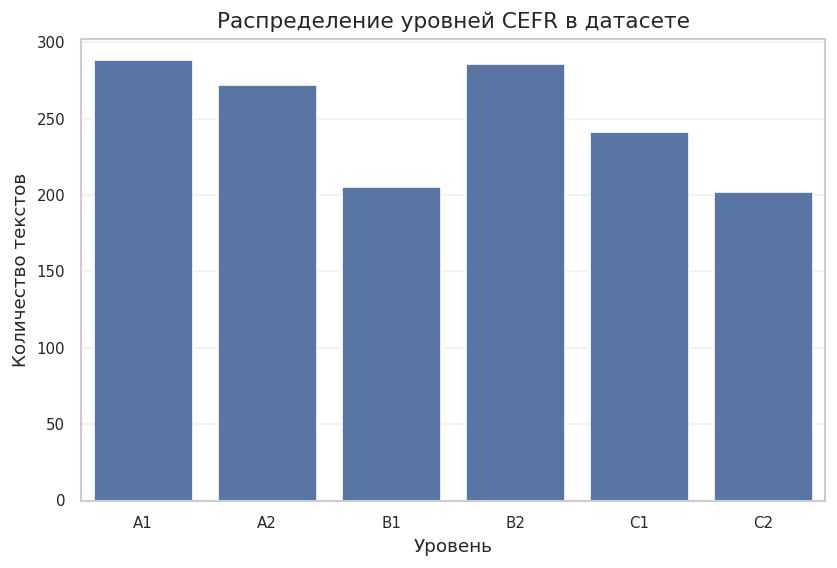


Train size: (1195,)
Test size: (299,)

Распределение классов в train:
label
A1    230
A2    217
B1    164
B2    229
C1    193
C2    162
Name: count, dtype: int64

Распределение классов в test:
label
A1    58
A2    55
B1    41
B2    57
C1    48
C2    40
Name: count, dtype: int64

Запуск обучения... Это может занять несколько минут.
Обучение завершено.

Оценка модели на тестовой выборке...

Accuracy: 0.5987
Macro F1: 0.5834
Weighted F1: 0.5914

Classification report:
              precision    recall  f1-score   support

          A1       0.75      0.86      0.80        58
          A2       0.70      0.67      0.69        55
          B1       0.52      0.27      0.35        41
          B2       0.44      0.51      0.47        57
          C1       0.44      0.50      0.47        48
          C2       0.74      0.70      0.72        40

    accuracy                           0.60       299
   macro avg       0.60      0.59      0.58       299
weighted avg       0.60      0.60      0.

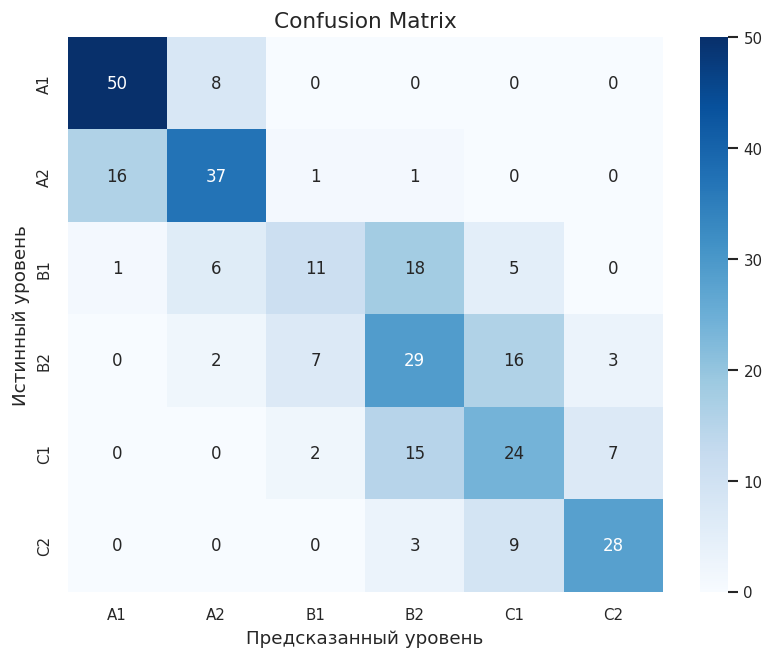

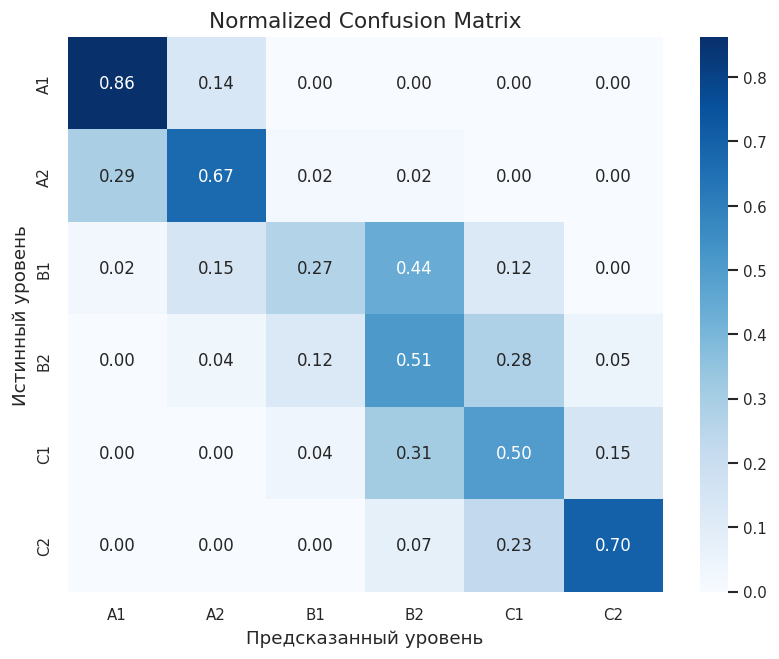

<Figure size 1200x720 with 0 Axes>

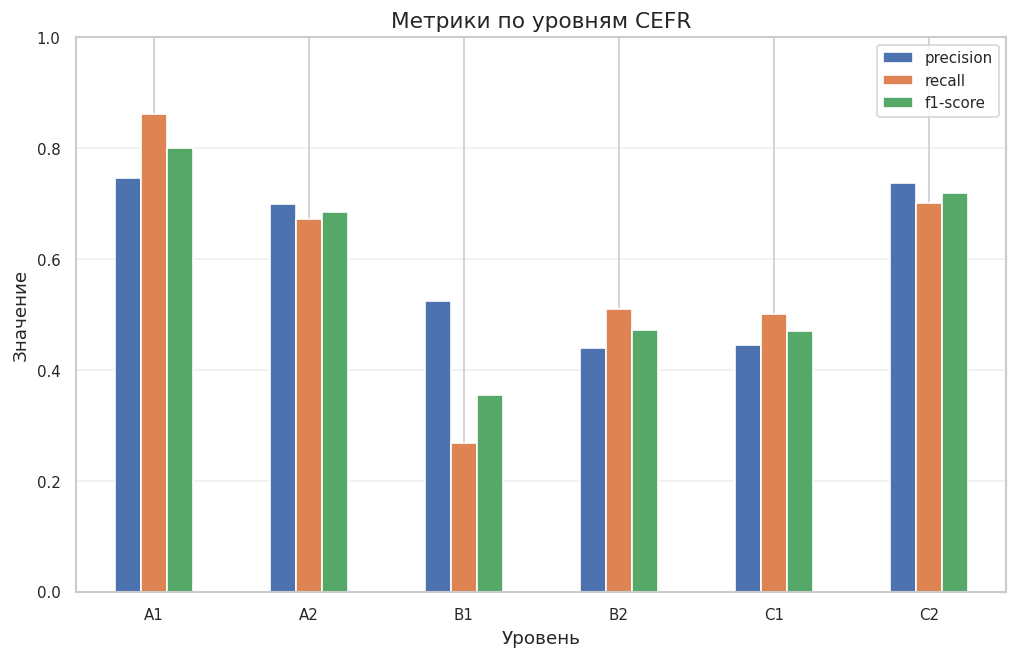



Тест A1:

АНАЛИЗ ТЕКСТА

Очищенный текст:
my name is anna. i am ten years old. i live in a small house with my mother and father. i like cats and dogs. every day i go to school. my favorite color is blue.

Определенный уровень: A1

Вероятности по уровням:
A1: 49.3%
A2: 42.5%
B2: 4.9%
B1: 1.8%
C1: 1.3%
C2: 0.2%


Тест B1/B2:

АНАЛИЗ ТЕКСТА

Очищенный текст:
many people believe that learning a foreign language is useful for travel and work. in my opinion, it also helps us understand other cultures. however, it can be difficult because students need to practise speaking, listening, reading and writing regularly.

Определенный уровень: A2

Вероятности по уровням:
A2: 41.2%
B1: 17.7%
A1: 14.2%
B2: 13.2%
C2: 8.0%
C1: 5.6%


Тест C1/C2:

АНАЛИЗ ТЕКСТА

Очищенный текст:
the increasing reliance on automated decision-making systems has raised complex questions about accountability, transparency and social impact. while such technologies can improve efficiency, their deployment requires careful

In [ ]:
import re
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)


# ============================================================
# 1. Загрузка датасета
# ============================================================



df = pd.read_csv("cefr_leveled_texts.csv")

print("Первые строки датасета:")
print(df.head())

print("\nКолонки датасета:")
print(df.columns)

print("\nРазмер датасета:")
print(df.shape)


# ============================================================
# 2. Проверка нужных колонок
# ============================================================

required_columns = ["text", "label"]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"В датасете нет обязательной колонки: {col}")


# ============================================================
# 3. Очистка текста
# ============================================================

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Возвращаем нормальные скобки, если в датасете есть такие обозначения
    text = text.replace("-LRB-", "(").replace("-RRB-", ")")

    # Заменяем переносы строк и табуляции на пробелы
    text = re.sub(r"[\n\r\t]+", " ", text)

    # Приводим разные типы апострофов к обычному апострофу
    text = text.replace("’", "'").replace("‘", "'").replace("`", "'")

    # Приводим разные тире к обычному дефису
    text = text.replace("—", "-").replace("–", "-")

    # Удаляем HTML-теги, если они есть
    text = re.sub(r"<.*?>", " ", text)

    # Оставляем английские буквы, цифры, пробелы и полезную пунктуацию
    text = re.sub(r"[^a-zA-Z0-9\s.,!?;:()\"'\-]", " ", text)

    # Убираем лишние пробелы перед знаками пунктуации
    text = re.sub(r"\s+([.,!?;:])", r"\1", text)

    # Убираем лишние пробелы после открывающей скобки
    text = re.sub(r"\(\s+", "(", text)

    # Убираем лишние пробелы перед закрывающей скобкой
    text = re.sub(r"\s+\)", ")", text)

    # Заменяем несколько пробелов подряд на один
    text = re.sub(r"\s+", " ", text)

    # Приводим к нижнему регистру
    text = text.lower().strip()

    return text


print("\nОчистка текста...")
df["cleaned_text"] = df["text"].apply(clean_text)

print("\nПример до очистки:")
print(str(df["text"].iloc[0])[:300])

print("\nПример после очистки:")
print(str(df["cleaned_text"].iloc[0])[:300])


# ============================================================
# 4. Очистка labels и удаление плохих строк
# ============================================================

df["label"] = df["label"].astype(str).str.strip().str.upper()

valid_labels = ["A1", "A2", "B1", "B2", "C1", "C2"]

df = df[df["label"].isin(valid_labels)]
df = df[df["cleaned_text"].str.len() > 0]

df = df.dropna(subset=["cleaned_text", "label"]).reset_index(drop=True)

print("\nРазмер датасета после очистки:")
print(df.shape)

print("\nРаспределение классов:")
print(df["label"].value_counts().reindex(valid_labels))


# ============================================================
# 5. График распределения классов
# ============================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="label", order=valid_labels)
plt.title("Распределение уровней CEFR в датасете")
plt.xlabel("Уровень")
plt.ylabel("Количество текстов")
plt.grid(axis="y", alpha=0.3)
plt.show()


# ============================================================
# 6. Разделение на train/test
# ============================================================

X = df["cleaned_text"].astype(str)
y = df["label"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

print("\nРаспределение классов в train:")
print(y_train.value_counts().reindex(valid_labels))

print("\nРаспределение классов в test:")
print(y_test.value_counts().reindex(valid_labels))


# ============================================================
# 7. Создание признаков
# ============================================================

features = FeatureUnion([
    (
        "word_features",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 3),
            max_features=30000,
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "char_features",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 6),
            max_features=30000,
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    )
])


# ============================================================
# 8. Создание модели
# ============================================================

base_model = LinearSVC(
    C=0.5,
    class_weight="balanced",
    random_state=42,
    max_iter=10000
)

pipeline = Pipeline([
    ("features", features),
    ("clf", base_model)
])


try:
    final_model = CalibratedClassifierCV(
        estimator=pipeline,
        cv=3,
        method="sigmoid"
    )
except TypeError:
    final_model = CalibratedClassifierCV(
        base_estimator=pipeline,
        cv=3,
        method="sigmoid"
    )


# ============================================================
# 9. Обучение модели
# ============================================================

print("\nЗапуск обучения... Это может занять несколько минут.")
final_model.fit(X_train, y_train)
print("Обучение завершено.")


# ============================================================
# 10. Оценка качества модели
# ============================================================

print("\nОценка модели на тестовой выборке...")

y_pred = final_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("\nAccuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=valid_labels,
        zero_division=0
    )
)


# ============================================================
# 11. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred, labels=valid_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=valid_labels,
    yticklabels=valid_labels
)
plt.title("Confusion Matrix")
plt.xlabel("Предсказанный уровень")
plt.ylabel("Истинный уровень")
plt.show()


# ============================================================
# 12. Нормализованная Confusion Matrix
# ============================================================

cm_norm = confusion_matrix(
    y_test,
    y_pred,
    labels=valid_labels,
    normalize="true"
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=valid_labels,
    yticklabels=valid_labels
)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Предсказанный уровень")
plt.ylabel("Истинный уровень")
plt.show()


# ============================================================
# 13. График precision / recall / f1-score
# ============================================================

report = classification_report(
    y_test,
    y_pred,
    labels=valid_labels,
    output_dict=True,
    zero_division=0
)

metrics_df = pd.DataFrame(report).T
metrics_df = metrics_df.loc[valid_labels, ["precision", "recall", "f1-score"]]

plt.figure(figsize=(10, 6))
metrics_df.plot(kind="bar", figsize=(10, 6))
plt.title("Метрики по уровням CEFR")
plt.xlabel("Уровень")
plt.ylabel("Значение")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.show()




# ============================================================
# 15. Функция для предсказания
# ============================================================

def evaluate_text(text):
    cleaned = clean_text(text)

    if len(cleaned.strip()) == 0:
        print("Текст пустой после очистки.")
        return None

    pred = final_model.predict([cleaned])[0]
    probs = final_model.predict_proba([cleaned])[0]
    classes = final_model.classes_

    results = sorted(
        zip(classes, probs),
        key=lambda x: x[1],
        reverse=True
    )

    print("\n" + "=" * 50)
    print("АНАЛИЗ ТЕКСТА")
    print("=" * 50)
    print("\nОчищенный текст:")
    print(cleaned[:500] + ("..." if len(cleaned) > 500 else ""))

    print("\nОпределенный уровень:", pred)

    print("\nВероятности по уровням:")
    for label, prob in results:
        print(f"{label}: {prob:.1%}")

    return pred


# ============================================================
# 16. Тестовые примеры
# ============================================================

print("\n\nТест A1:")
evaluate_text("""
My name is Anna. I am ten years old. I live in a small house with my mother and father.
I like cats and dogs. Every day I go to school. My favorite color is blue.
""")

print("\n\nТест B1/B2:")
evaluate_text("""
Many people believe that learning a foreign language is useful for travel and work.
In my opinion, it also helps us understand other cultures. However, it can be difficult
because students need to practise speaking, listening, reading and writing regularly.
""")

print("\n\nТест C1/C2:")
evaluate_text("""
The increasing reliance on automated decision-making systems has raised complex questions
about accountability, transparency and social impact. While such technologies can improve
efficiency, their deployment requires careful evaluation, particularly when outcomes affect
education, employment or access to essential services.
""")


# ============================================================
# 17. Сохранение модели
# ============================================================

joblib.dump(final_model, "cefr_expert_model.pkl")
print("\nМодель сохранена как cefr_expert_model.pkl")


# ============================================================
# 18. Пример загрузки сохраненной модели
# ============================================================

# loaded_model = joblib.load("cefr_expert_model.pkl")
# prediction = loaded_model.predict([clean_text("I like my school. I have many friends.")])[0]
# print(prediction)

В этой части работы была обучена вторая модель для классификации англоязычных текстов на четыре класса: `children`, `educational`, `science` и `business`. Общий датасет был составлен из нескольких источников: детские тексты и научные статьи были найдены на Kaggle, образовательные тексты были собраны вручную из учебных пособий разных уровней, а бизнес-тексты были взяты из датасета бизнес-статей и газетных материалов.


## Описание датасета

Для обучения модели был составлен общий датасет, объединяющий данные из четырех разных источников. Каждый текст был отнесен к одному из четырех классов. Разметка выполнялась на основе назначения текста, его тематики, сложности лексики и предполагаемой аудитории.

Использовались следующие классы:

**children** — тексты для чтения, подходящие детям младших классов и дошкольникам. Для этого класса был найден подходящий датасет на Kaggle. В него входят простые тексты с доступной лексикой, короткими предложениями и понятными сюжетами. Такие тексты могут использоваться для начального изучения английского языка и развития базовых навыков чтения.

**educational** — учебные тексты, собранные вручную из образовательных пособий разных уровней. Этот класс включает материалы, подходящие для старших школьников и студентов непрофильных образовательных учреждений. Тексты имеют более сложную структуру по сравнению с детскими, но при этом ориентированы на обучение, развитие навыков чтения и понимание общеобразовательных тем.

**science** — научные тексты, основанные на датасете научных статей, найденном на Kaggle. Данный класс включает материалы с академической лексикой, терминами и более сложным синтаксисом. Такие тексты подходят для чтения студентами профильных образовательных учреждений, а также для пользователей, которым необходимо развивать навыки понимания научного английского.

**business** — тексты из бизнес-статей и газетных материалов, также найденные на Kaggle. Этот класс включает лексику, связанную с экономикой, компаниями, финансами, рынками, переговорами и деловой коммуникацией. Такие тексты могут быть полезны для улучшения бизнес-английского, подготовки к конференциям, деловым встречам и переговорам.

После объединения данных итоговый датасет был разделен на три части: обучающую выборку, валидационную выборку и тестовую выборку. Обучающая выборка использовалась для обучения модели, валидационная — для промежуточной оценки качества, а тестовая — для финальной проверки способности модели классифицировать новые тексты.

## Используемая модель

В качестве модели была использована классическая модель машинного обучения для обработки текстов: связка `TF-IDF Vectorizer` и `Logistic Regression`.

Сначала тексты преобразовывались в числовое представление с помощью метода **TF-IDF**. Этот метод позволяет оценить важность слов и словосочетаний в тексте с учетом того, насколько часто они встречаются в конкретном документе и во всем корпусе. Благодаря этому модель может учитывать характерную лексику каждого класса.

Векторизатор был настроен следующим образом:

- все тексты приводились к нижнему регистру;
- использовались униграммы и биграммы, то есть отдельные слова и пары слов;
- максимальное количество признаков было ограничено 50 000;
- слишком редкие слова отбрасывались с помощью параметра `min_df=2`;
- слишком частые слова отбрасывались с помощью параметра `max_df=0.95`;
- использовалось сглаживание частот через `sublinear_tf=True`.

После преобразования текстов в TF-IDF-признаки применялась модель **логистической регрессии**. Несмотря на название, логистическая регрессия хорошо подходит не только для бинарной, но и для многоклассовой классификации. В данной работе она использовалась для определения одного из четырех классов текста.

## Оценка качества модели

Для оценки качества модели использовались несколько метрик классификации.

Основной метрикой была **accuracy** — доля правильно классифицированных текстов среди всех текстов выборки. Эта метрика позволяет оценить общее качество модели.

Также использовались метрики:

**Precision** — показывает, насколько точны предсказания модели для каждого класса. Например, если модель отнесла текст к классу `science`, precision показывает, как часто такие предсказания действительно были правильными.

**Recall** — показывает, какую долю объектов конкретного класса модель смогла правильно найти. Например, recall для класса `children` показывает, сколько реальных детских текстов модель смогла распознать.

**F1-score** — объединяет precision и recall в одну метрику. Она особенно полезна, если важно учитывать как точность предсказаний, так и полноту обнаружения объектов каждого класса.

Дополнительно была построена **confusion matrix** — матрица ошибок. Она показывает, какие классы модель чаще всего путает между собой. Это помогает анализировать слабые места модели. Например, если модель часто путает `educational` и `science`, это может быть связано с тем, что оба класса содержат учебную или академическую лексику.

## Визуализация результатов

Для удобного анализа качества модели были построены графики:

- сравнение accuracy на validation и test выборках;
- значения precision, recall и F1-score по каждому классу на test выборке;
- сравнение F1-score на validation и test выборках;
- confusion matrix в абсолютных значениях;
- confusion matrix в процентах.

Такая визуализация позволяет не только увидеть итоговое качество модели, но и понять, какие классы распознаются лучше, а какие требуют дополнительной доработки датасета или модели.

## Анализ ошибок

После тестирования модели были отдельно сохранены ошибочные предсказания. Для каждого текста указывались его настоящий класс и предсказанный моделью класс. Это позволяет вручную проанализировать ошибки и понять, почему модель могла принять неправильное решение.

Например, тексты классов `educational` и `science` могут быть похожи по структуре и лексике, так как оба могут содержать сложные объяснения и академические выражения. Аналогично, некоторые тексты класса `business` могут пересекаться с `educational`, если они написаны в обучающем стиле.

## Сохранение модели и результатов

После обучения модель была сохранена в файл `tfidf_logreg_4class_model.joblib`. Это позволяет использовать ее повторно без необходимости заново обучать модель.

Также были сохранены результаты предсказаний на тестовой выборке:

- `test_predictions_4class.csv` — файл со всеми тестовыми примерами, предсказанными классами и вероятностями по каждому классу;
- `test_errors_4class.csv` — файл только с ошибочными предсказаниями модели.

Дополнительно модель была проверена на нескольких собственных примерах текстов. Для каждого примера модель определяла наиболее вероятный класс и выводила вероятности принадлежности к каждому из четырех классов.

## Итог

Таким образом, была построена модель классификации англоязычных текстов на четыре категории: детские тексты, образовательные тексты, научные тексты и бизнес-тексты. Модель основана на TF-IDF-представлении текста и логистической регрессии. Такой подход является интерпретируемым, достаточно быстрым и хорошо подходит для базовой классификации текстовых данных.

Полученная модель может использоваться как часть системы подбора текстов для чтения в зависимости от целей пользователя: начальное обучение английскому языку, учебное чтение, работа с научными материалами или развитие бизнес-английского.

In [ ]:
import pandas as pd
import csv

file_path = "children_dataset.csv"

df_children = pd.read_csv(
    file_path,
    engine="python",
    on_bad_lines="skip",
    quoting=csv.QUOTE_MINIMAL
)

print("Загружено строк:", len(df_children))
print("Колонки:", df_children.columns.tolist())
df_children.head()

Загружено строк: 54769
Колонки: ['text']


,text
0,"One day, a little girl named Lily found a need..."
1,"Once upon a time, there was a little car named..."
2,"One day, a little fish named Fin was swimming ..."
3,"Once upon a time, in a land full of trees, the..."
4,"Once upon a time, there was a little girl name..."


In [ ]:
df_children = df_children.sample(n=min(5000, len(df_children)), random_state=42)

print(df_children.shape)
print(df_children.head())

(5000, 1)
                                                    text
20182  Max's family took a walk. He was so excited to...
18809  Once upon a time there was a purple flower. It...
41776  Once upon a time there was a little plant that...
12900  Once upon a time, there was a little girl name...
18965  Once upon a time there was a little bird calle...


In [ ]:
len(df_children)

NameError: name 'df_children' is not defined

In [ ]:
import pandas as pd

df_academic_raw = pd.read_csv(
    "educational.csv",
    on_bad_lines="skip",
    engine="python"
)

print("Колонки:", df_academic_raw.columns.tolist())
print("Успешно загружено строк:", len(df_academic_raw))
df_academic_raw.head()

Колонки: ['text', 'label']
Успешно загружено строк: 3000


,text,label
0,"agency, and I only went into it because I've a...",educational
1,University is rooted in liberal arts education...,educational
2,one occasion in several houses at a time. The ...,educational
3,"of their outlets, and replacing the old names ...",educational
4,"to bed until they knew it. ""Yes, we had to wor...",educational


In [ ]:
df_academic_raw = df_academic_raw.sample(n=min(5000, len(df_academic_raw)), random_state=42)

print(df_academic_raw.shape)
print(df_academic_raw.head())

(3000, 2)
                                                   text        label
1801  garden was gay with flowers. "Here's Kirrin Co...  educational
1190  in desert; and these deserts are growing. The ...  educational
1817  sent to prison. b. A doctor finds he can cure ...  educational
251   home for medical attention. The priest also to...  educational
2505  answer I catch a glimpse of dark eyes, stubble...  educational


In [ ]:
print(df_academic_raw['label'].value_counts())

label
educational    3000
Name: count, dtype: int64


In [ ]:
import pandas as pd
import csv

science_path = "science.csv"

df_science_raw = pd.read_csv(
    science_path,
    engine="python",
    on_bad_lines="skip",
    quoting=csv.QUOTE_MINIMAL
)

print("Загружено строк:", len(df_science_raw))
print("Колонки:", df_science_raw.columns.tolist())
df_science_raw.head()

Загружено строк: 7701
Колонки: ['paper_id', 'title', 'authors', 'num_authors', 'first_author', 'abstract', 'abstract_length', 'word_count', 'primary_category', 'all_categories', 'num_categories', 'submitted_date', 'updated_date', 'year', 'month', 'has_journal_ref', 'journal_ref', 'comment', 'has_doi', 'doi', 'arxiv_url', 'pdf_url', 'is_large_collaboration', 'is_updated', 'update_lag_days', 'days_since_submission']


,paper_id,title,authors,num_authors,first_author,abstract,abstract_length,word_count,primary_category,all_categories,...,journal_ref,comment,has_doi,doi,arxiv_url,pdf_url,is_large_collaboration,is_updated,update_lag_days,days_since_submission
0,2604.26951v1,Turning the TIDE: Cross-Architecture Distillat...,Gongbo Zhang; Wen Wang; Ye Tian; Li Yuan,4,Gongbo Zhang,Diffusion large language models (dLLMs) offer ...,1269,167,cs.CL,cs.CL; cs.AI; cs.LG,...,Not Available,"15 pages, 3 figures. Code: https://github.com/...",0,Not Available,https://arxiv.org/abs/2604.26951v1,https://arxiv.org/pdf/2604.26951v1,0,0,0,1
1,2604.26231v1,ProMax: Exploring the Potential of LLM-derived...,Yi Zhang; Yiwen Zhang; Kai Zheng; Tong Chen; H...,5,Yi Zhang,The remarkable text understanding and generati...,1748,233,cs.IR,cs.IR,...,Not Available,"11 pages, 8 figures, accepted by SIGIR 2026",0,Not Available,https://arxiv.org/abs/2604.26231v1,https://arxiv.org/pdf/2604.26231v1,0,0,0,1
2,2604.26567v1,AirZoo: A Unified Large-Scale Dataset for Grou...,Xiaoya Cheng; Rouwan Wu; Xinyi Liu; Zeyu Cui; ...,9,Xiaoya Cheng,Despite the rapid progress in data-driven 3D v...,1692,217,cs.CV,cs.CV,...,Not Available,No comment,0,Not Available,https://arxiv.org/abs/2604.26567v1,https://arxiv.org/pdf/2604.26567v1,0,0,0,1
3,2604.26565v1,"DenseStep2M: A Scalable, Training-Free Pipelin...",Mingji Ge; Qirui Chen; Zeqian Li; Weidi Xie,4,Mingji Ge,Long-term video understanding requires interpr...,1758,204,cs.CV,cs.CV,...,Not Available,No comment,0,Not Available,https://arxiv.org/abs/2604.26565v1,https://arxiv.org/pdf/2604.26565v1,0,0,0,1
4,2604.26520v1,3D-LENS: A 3D Lifting-based Elevated Novel-vie...,William Grolleau; Astrid Sabourin; Guillaume L...,4,William Grolleau,Aerial-Ground Re-Identification (AG-ReID) is c...,1418,174,cs.CV,cs.CV,...,Not Available,No comment,0,Not Available,https://arxiv.org/abs/2604.26520v1,https://arxiv.org/pdf/2604.26520v1,0,0,0,1


In [ ]:
df_science_final = df_science_raw.copy()

df_science_final["text"] = df_science_final["title"].fillna("").astype(str)

df_science_final = df_science_final[["text"]].copy()
df_science_final["label"] = "science"

df_science_final["text"] = (
    df_science_final["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_science_final = df_science_final[df_science_final["text"].str.len() > 10]
df_science_final = df_science_final.drop_duplicates(subset=["text"])

print("Science final:", df_science_final.shape)
print(df_science_final["label"].value_counts())
df_science_final.head()

Science final: (7699, 2)
label
science    7699
Name: count, dtype: int64


,text,label
0,Turning the TIDE: Cross-Architecture Distillat...,science
1,ProMax: Exploring the Potential of LLM-derived...,science
2,AirZoo: A Unified Large-Scale Dataset for Grou...,science
3,"DenseStep2M: A Scalable, Training-Free Pipelin...",science
4,3D-LENS: A 3D Lifting-based Elevated Novel-vie...,science


In [ ]:
import pandas as pd
import re

df_business_raw = pd.read_csv(
    "business.csv",
    encoding="latin1"
)

print("Raw shape:", df_business_raw.shape)
print("Колонки:", df_business_raw.columns.tolist())
display(df_business_raw.head())

df_business = df_business_raw[["text"]].copy()

df_business["label"] = "business"

df_business["text"] = (
    df_business["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_business = df_business[df_business["text"].str.len() > 50]
df_business = df_business.drop_duplicates(subset="text")
df_business = df_business.reset_index(drop=True)

print("Final shape:", df_business.shape)
print(df_business["label"].value_counts())
display(df_business.head())

Raw shape: (31603, 2)
Колонки: ['text', 'sentiment']


,text,sentiment
0,Innovatech Solutions reported a 15% increase i...,positive
1,"During fiscal year 2023, GreenTech Energy expa...",positive
2,MegaRetail Group's Q2 earnings exceeded foreca...,positive
3,Following its recent acquisition of SmartLogis...,positive
4,Eagle Pharmaceuticals announced a successful l...,positive


Final shape: (31602, 2)
label
business    31602
Name: count, dtype: int64


,text,label
0,Innovatech Solutions reported a 15% increase i...,business
1,"During fiscal year 2023, GreenTech Energy expa...",business
2,MegaRetail Group's Q2 earnings exceeded foreca...,business
3,Following its recent acquisition of SmartLogis...,business
4,Eagle Pharmaceuticals announced a successful l...,business


проверяем количество данных в каждом датасете

In [ ]:
datasets_stats = pd.DataFrame({
    "dataset": [
        "children",
        "academic",
        "science",
        "business"
    ],
    "count": [
        len(df_children),
        len(df_academic_raw),
        len(df_science_final),
        len(df_business)
    ]
})

datasets_stats

,dataset,count
0,children,5000
1,academic,3000
2,science,7699
3,business,31602


In [ ]:
import pandas as pd

# 1. Объединяем все датасеты
df_all = pd.concat(
    [
        df_children,
        df_academic_raw,
        df_science_final,
        df_business
    ],
    ignore_index=True
)

# 2. Оставляем только нужные колонки
df_all = df_all[["text", "label"]].copy()

# 3. Чистим text и label
df_all["text"] = df_all["text"].astype(str)
df_all["label"] = df_all["label"].astype(str)

df_all["text"] = (
    df_all["text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_all["label"] = (
    df_all["label"]
    .str.strip()
    .str.lower()
)

# 4. Удаляем пустые и слишком короткие тексты
df_all = df_all[df_all["text"].notna()]
df_all = df_all[df_all["text"].str.len() > 10]

# 5. Удаляем дубликаты
df_all = df_all.drop_duplicates(subset=["text"])

print("После объединения и чистки:")
print(df_all["label"].value_counts())
print("Форма:", df_all.shape)
print()

# 6. Балансируем классы до 3000
TARGET_SIZE = 3000

balanced_parts = []

for label, group in df_all.groupby("label"):
    print(label, len(group))

    sampled = group.sample(
        n=min(TARGET_SIZE, len(group)),
        random_state=42
    )

    balanced_parts.append(sampled)

df_balanced = pd.concat(balanced_parts, ignore_index=True)

# 7. Перемешиваем
df_balanced = (
    df_balanced
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# 8. Проверяем результат
print("Финальный датасет:")
print(df_balanced["label"].value_counts())
print("Форма:", df_balanced.shape)
print("Уникальные label:", df_balanced["label"].unique())

display(df_balanced.head())

# 9. Сохраняем
df_balanced.to_csv("final_4class_balanced_dataset.csv", index=False)

print("Saved: final_4class_balanced_dataset.csv")

После объединения и чистки:
label
business       31602
science         7699
children        4999
educational     3000
Name: count, dtype: int64
Форма: (47300, 2)

business 31602
children 4999
educational 3000
science 7699
Финальный датасет:
label
business       3000
educational    3000
science        3000
children       3000
Name: count, dtype: int64
Форма: (12000, 2)
Уникальные label: ['business' 'educational' 'science' 'children']


,text,label
0,"During FY23, AeroLogistics expanded cargo operations in Europe, achieving a 25% increase in load factor and a net op...",business
1,"perform in high-risk environments, whether that is a power station or a mine-field. After all, the loss of a robot i...",educational
2,South Korean conglomerate Hyundai Heavy Industries reported a backlog reduction and profit slump due to the global s...,business
3,Efficient Dataset Selection for Continual Adaptation of Generative Recommenders,science
4,Automotive dealership group RoadStar recorded lower year-end sales with profit margins squeezed due to higher incent...,business


Saved: final_4class_balanced_dataset.csv


выводим случайные тексты с каждого класса чтобы убедитьсяв правильности отображения

In [ ]:
import pandas as pd

df = pd.read_csv("final_4class_balanced_dataset.csv")

print(df.shape)
print(df.head())
print(df.columns)
print(df["label"].value_counts())
for class_name in sorted(df["label"].unique()):
    print("\n" + "=" * 100)
    print(f"CLASS: {class_name}")
    print("=" * 100)

    samples = df[df["label"] == class_name].sample(3, random_state=42)

    for idx, text in enumerate(samples["text"], 1):
        print(f"\nExample {idx}:")
        print(text[:1000])

(12000, 2)
                                                                                                                      text        label
0  During FY23, AeroLogistics expanded cargo operations in Europe, achieving a 25% increase in load factor and a net op...     business
1  perform in high-risk environments, whether that is a power station or a mine-field. After all, the loss of a robot i...  educational
2  South Korean conglomerate Hyundai Heavy Industries reported a backlog reduction and profit slump due to the global s...     business
3                                          Efficient Dataset Selection for Continual Adaptation of Generative Recommenders      science
4  Automotive dealership group RoadStar recorded lower year-end sales with profit margins squeezed due to higher incent...     business
Index(['text', 'label'], dtype='object')
label
business       3000
educational    3000
science        3000
children       3000
Name: count, dtype: int64

CLASS: business

Ex

In [ ]:
from sklearn.model_selection import train_test_split

df_balanced = df_balanced[["text", "label"]].copy()

# Проверяем распределение классов до разделения
print("Исходный датасет:")
print(df_balanced["label"].value_counts())
print("Форма:", df_balanced.shape)
print()

# 1. Сначала отделяем test: 10%
train_val_df, test_df = train_test_split(
    df_balanced,
    test_size=0.10,
    random_state=42,
    stratify=df_balanced["label"]
)

# 2. Потом из оставшихся 90% отделяем validation
train_df, val_df = train_test_split(
    train_val_df,
    test_size=1/9,
    random_state=42,
    stratify=train_val_df["label"]
)

# Проверяем размеры
print("Размеры выборок:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print()

# Проверяем распределение классов
print("Train labels:")
print(train_df["label"].value_counts())
print()

print("Validation labels:")
print(val_df["label"].value_counts())
print()

print("Test labels:")
print(test_df["label"].value_counts())
print()

# Сохраняем файлы
train_df.to_csv("train_4class.csv", index=False)
val_df.to_csv("val_4class.csv", index=False)
test_df.to_csv("test_4class.csv", index=False)

print("Saved:")
print("train_4class.csv")
print("val_4class.csv")
print("test_4class.csv")

Исходный датасет:
label
business       3000
educational    3000
science        3000
children       3000
Name: count, dtype: int64
Форма: (12000, 2)

Размеры выборок:
Train: (9600, 2)
Validation: (1200, 2)
Test: (1200, 2)

Train labels:
label
educational    2400
children       2400
science        2400
business       2400
Name: count, dtype: int64

Validation labels:
label
business       300
children       300
educational    300
science        300
Name: count, dtype: int64

Test labels:
label
science        300
children       300
business       300
educational    300
Name: count, dtype: int64

Saved:
train_4class.csv
val_4class.csv
test_4class.csv


Train: (9600, 2)
Validation: (1200, 2)
Test: (1200, 2)

Train labels:
label
educational    2400
children       2400
science        2400
business       2400
Name: count, dtype: int64

Validation labels:
label
business       300
children       300
educational    300
science        300
Name: count, dtype: int64

Test labels:
label
science        300
children       300
business       300
educational    300
Name: count, dtype: int64

Training started...
Training finished.

VALIDATION RESULTS
Validation accuracy: 0.9983333333333333

Classification report:
              precision    recall  f1-score   support

    business       1.00      1.00      1.00       300
    children       1.00      1.00      1.00       300
 educational       1.00      1.00      1.00       300
     science       1.00      0.99      1.00       300

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200


TEST RES

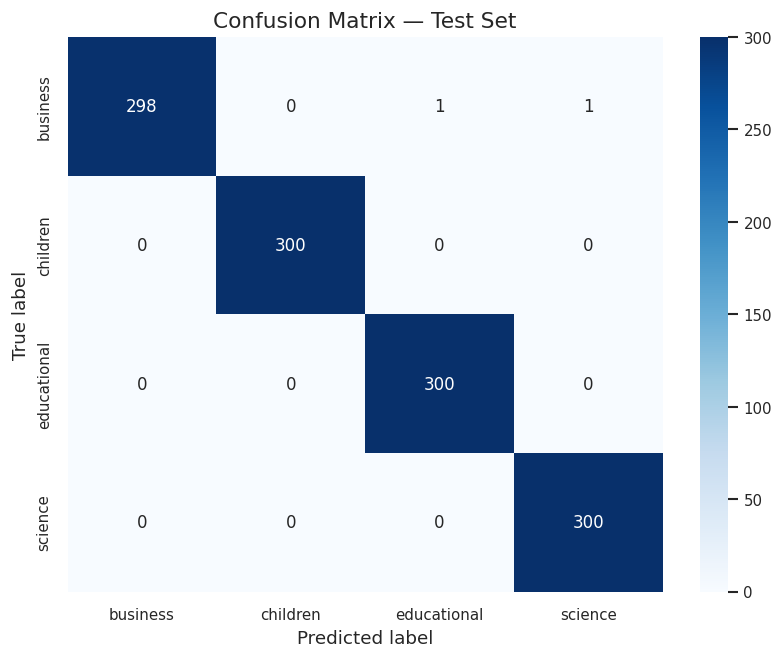


Ошибок на test: 2

Примеры ошибок:
                                                                                                                        text     label predicted_label
799  TechInnovate's R&D department received additional funding to accelerate AI development, focusing on natural language...  business         science
924                         The audit concluded that no irregularities were found in the billing processes of InfoServe Inc.  business     educational

Результаты с вероятностями:
                                                                                                                       text        label predicted_label  is_correct  proba_business  proba_children  \
0                               ATRS: Adaptive Trajectory Re-splitting via a Shared Neural Policy for Parallel Optimization      science         science        True        0.007529        0.002024   
1   Once upon a time, there was a fat cat named Spot. Spot loved to play and run a

In [ ]:
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# 1. Загрузка файлов
# =========================

train_df = pd.read_csv("train_4class.csv")
val_df = pd.read_csv("val_4class.csv")
test_df = pd.read_csv("test_4class.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())


# =========================
# 2. Подготовка данных
# =========================

X_train = train_df["text"].astype(str)
y_train = train_df["label"].astype(str)

X_val = val_df["text"].astype(str)
y_val = val_df["label"].astype(str)

X_test = test_df["text"].astype(str)
y_test = test_df["label"].astype(str)


# =========================
# 3. Модель TF-IDF + LogisticRegression
# =========================

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        n_jobs=-1,
        random_state=42
    ))
])


# =========================
# 4. Обучение
# =========================

print("\nTraining started...")
model.fit(X_train, y_train)
print("Training finished.")


# =========================
# 5. Validation
# =========================

val_pred = model.predict(X_val)

print("\nVALIDATION RESULTS")
print("Validation accuracy:", accuracy_score(y_val, val_pred))
print("\nClassification report:")
print(classification_report(y_val, val_pred))


# =========================
# 6. Test
# =========================

test_pred = model.predict(X_test)

print("\nTEST RESULTS")
print("Test accuracy:", accuracy_score(y_test, test_pred))
print("\nClassification report:")
print(classification_report(y_test, test_pred))


# =========================
# 7. Confusion Matrix
# =========================

labels = ["business", "children", "educational", "science"]

cm = confusion_matrix(y_test, test_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — Test Set")
plt.show()


# =========================
# 8. Ошибки модели
# =========================

errors_df = test_df.copy()
errors_df["predicted_label"] = test_pred
errors_df["is_correct"] = errors_df["label"] == errors_df["predicted_label"]

wrong_df = errors_df[errors_df["is_correct"] == False].copy()

print("\nОшибок на test:", len(wrong_df))

print("\nПримеры ошибок:")
print(wrong_df[["text", "label", "predicted_label"]].head(20))


# =========================
# 9. Вероятности
# =========================

test_proba = model.predict_proba(X_test)
model_classes = model.classes_

proba_df = pd.DataFrame(
    test_proba,
    columns=[f"proba_{cls}" for cls in model_classes]
)

result_df = test_df.copy().reset_index(drop=True)
result_df["predicted_label"] = test_pred
result_df["is_correct"] = result_df["label"] == result_df["predicted_label"]

result_df = pd.concat([result_df, proba_df], axis=1)

print("\nРезультаты с вероятностями:")
print(result_df.head(20))


# =========================
# 10. Сохранение результатов
# =========================

result_df.to_csv("test_predictions_4class.csv", index=False)
wrong_df.to_csv("test_errors_4class.csv", index=False)

print("\nSaved:")
print("test_predictions_4class.csv")
print("test_errors_4class.csv")


# =========================
# 11. Сохранение модели
# =========================

joblib.dump(model, "tfidf_logreg_4class_model.joblib")

print("\nModel saved:")
print("tfidf_logreg_4class_model.joblib")


# =========================
# 12. Проверка на своих примерах
# =========================

examples = [
    "The company reported a strong increase in quarterly revenue and net profit.",
    "Once upon a time, a small rabbit lived in a magical forest.",
    "This paper introduces a new transformer architecture for image generation.",
    "Students should read the passage and answer the following questions."
]

example_pred = model.predict(examples)
example_proba = model.predict_proba(examples)

example_result = pd.DataFrame({
    "text": examples,
    "predicted_label": example_pred
})

for i, cls in enumerate(model.classes_):
    example_result[f"proba_{cls}"] = example_proba[:, i]

print("\nПроверка на своих примерах:")
print(example_result)

/tmp/ipykernel_385/3255161904.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


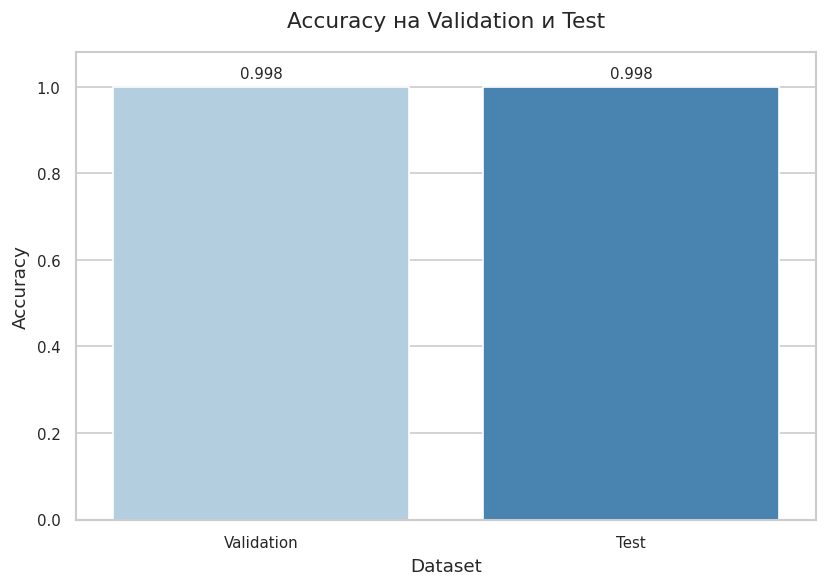

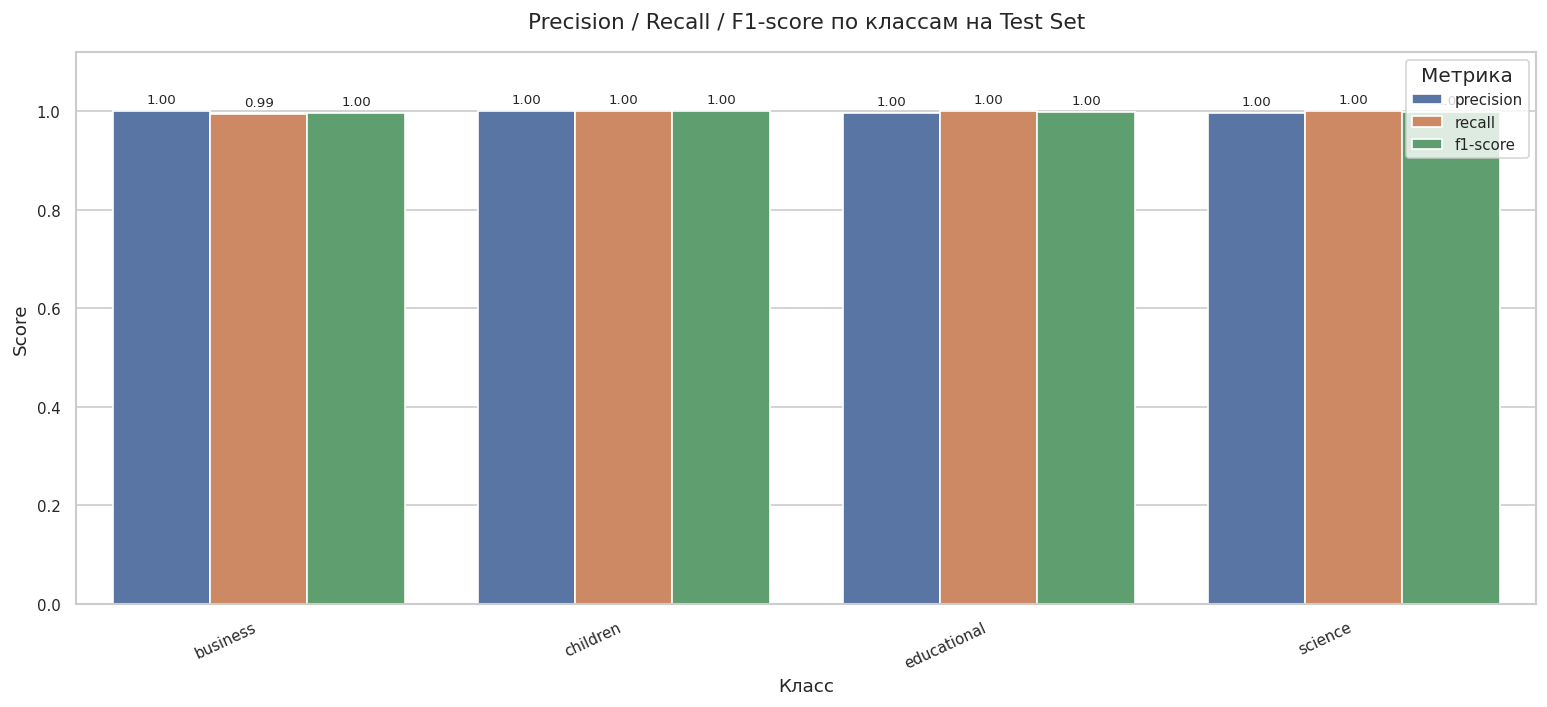

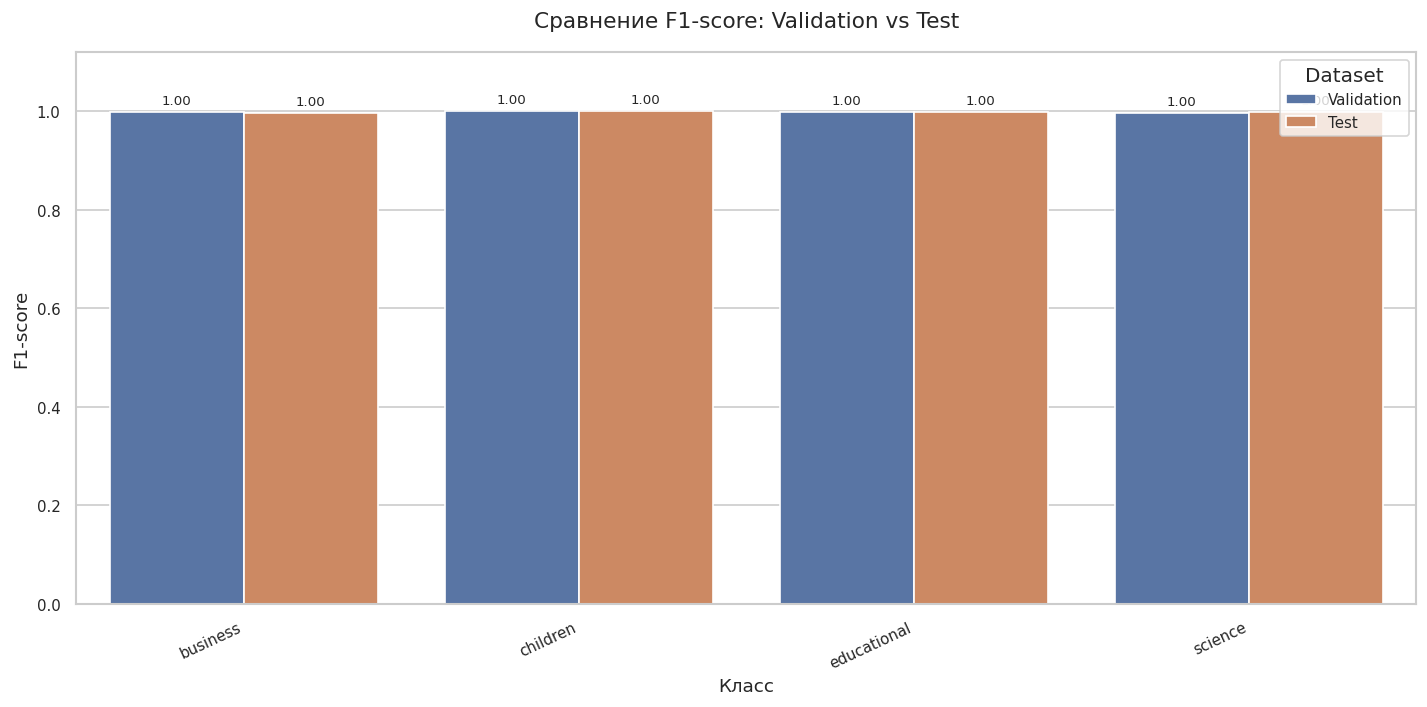

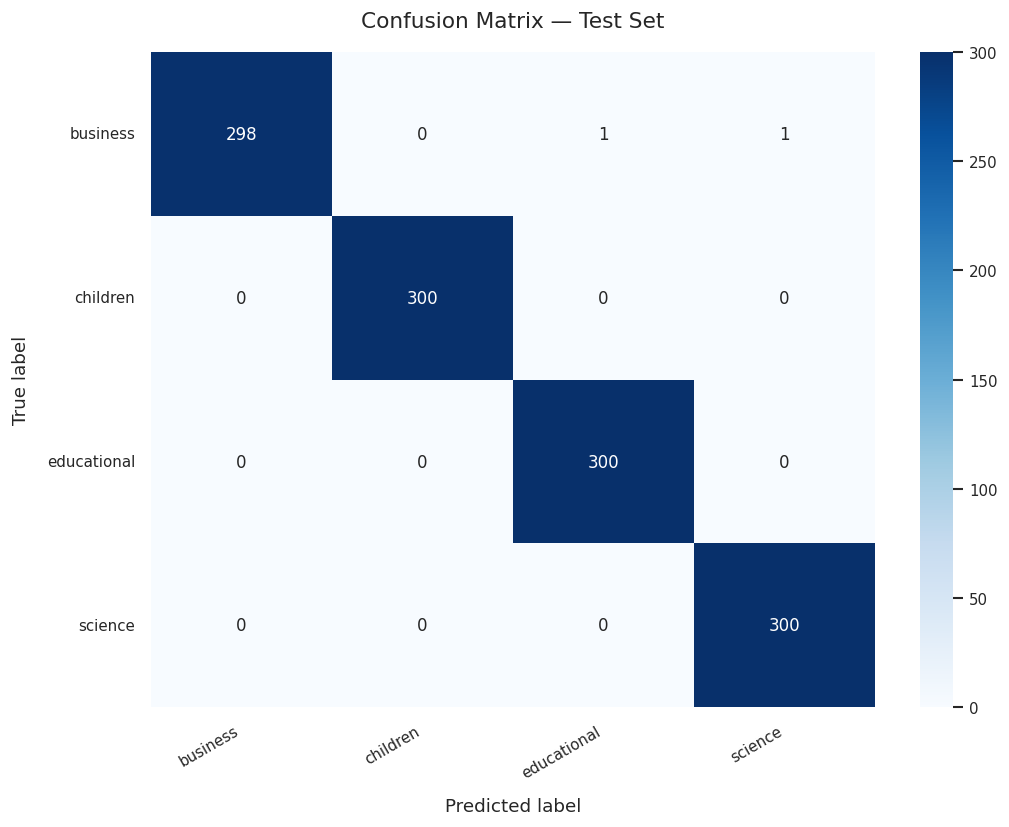

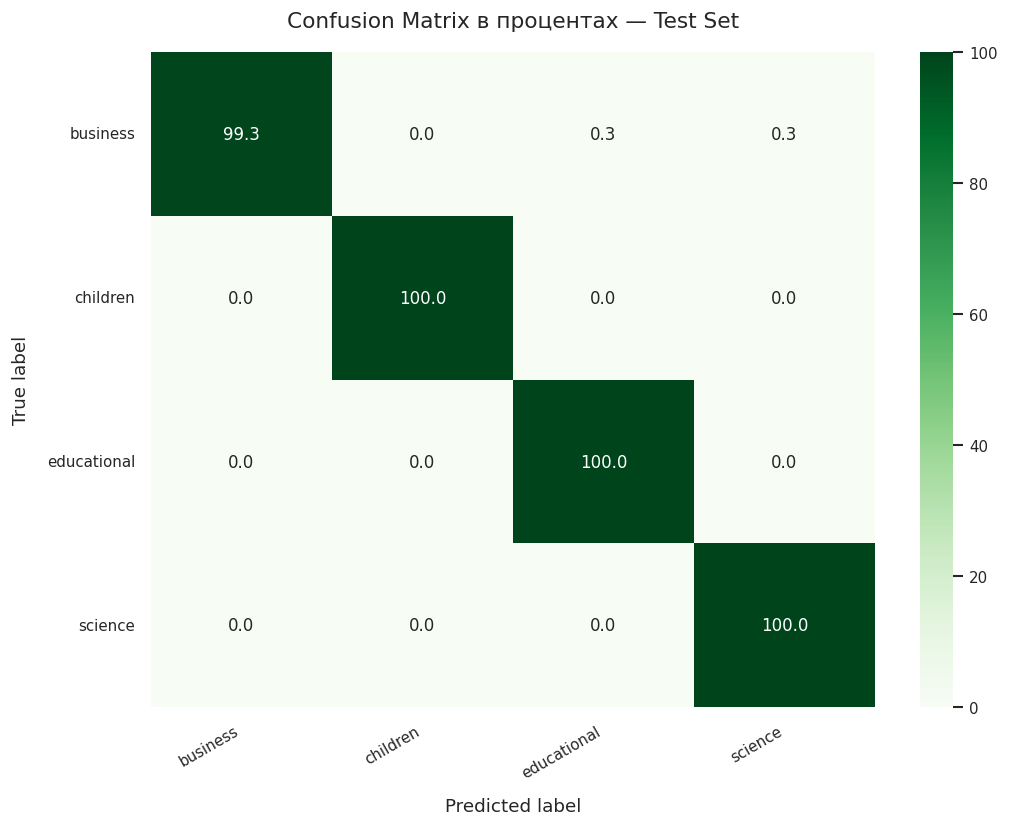

In [ ]:
# =========================
# ВИЗУАЛИЗАЦИЯ МЕТРИК
# =========================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)


sns.set_theme(style="whitegrid")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 9

# Названия классов
labels = ["business", "children", "educational", "science"]

# =========================
# Расчет метрик
# =========================

val_accuracy = accuracy_score(y_val, val_pred)
test_accuracy = accuracy_score(y_test, test_pred)

val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
    y_val,
    val_pred,
    labels=labels,
    zero_division=0
)

test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test,
    test_pred,
    labels=labels,
    zero_division=0
)

# =========================
# 1. Accuracy Validation vs Test
# =========================

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=["Validation", "Test"],
    y=[val_accuracy, test_accuracy],
    palette="Blues"
)

plt.ylim(0, 1.08)
plt.title("Accuracy на Validation и Test", pad=15)
plt.xlabel("Dataset")
plt.ylabel("Accuracy")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=4, fontsize=9)

plt.tight_layout()
plt.show()

# =========================
# 2. Precision / Recall / F1 на Test
# =========================

metrics_df = pd.DataFrame({
    "class": labels,
    "precision": test_precision,
    "recall": test_recall,
    "f1-score": test_f1
})

metrics_melted = metrics_df.melt(
    id_vars="class",
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(13, 6))

ax = sns.barplot(
    data=metrics_melted,
    x="class",
    y="score",
    hue="metric"
)

plt.ylim(0, 1.12)
plt.title("Precision / Recall / F1-score по классам на Test Set", pad=15)
plt.xlabel("Класс")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Метрика", loc="upper right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

# =========================
# 3. Сравнение F1-score Validation vs Test
# =========================

f1_compare_df = pd.DataFrame({
    "class": labels,
    "Validation": val_f1,
    "Test": test_f1
})

f1_compare_melted = f1_compare_df.melt(
    id_vars="class",
    var_name="dataset",
    value_name="f1_score"
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=f1_compare_melted,
    x="class",
    y="f1_score",
    hue="dataset"
)

plt.ylim(0, 1.12)
plt.title("Сравнение F1-score: Validation vs Test", pad=15)
plt.xlabel("Класс")
plt.ylabel("F1-score")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Dataset", loc="upper right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

# =========================
# 4. Confusion Matrix в числах
# =========================

cm = confusion_matrix(y_test, test_pred, labels=labels)

plt.figure(figsize=(9, 7))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 10}
)

plt.xlabel("Predicted label", labelpad=10)
plt.ylabel("True label", labelpad=10)
plt.title("Confusion Matrix — Test Set", pad=15)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# =========================
# 5. Confusion Matrix в процентах
# =========================

cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(9, 7))

ax = sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 10}
)

plt.xlabel("Predicted label", labelpad=10)
plt.ylabel("True label", labelpad=10)
plt.title("Confusion Matrix в процентах — Test Set", pad=15)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Тестовые примеры
examples = [
    "The company reported strong quarterly revenue growth and increased market share.",
    "Once upon a time, there was a little rabbit who lived in a forest.",
    "Photosynthesis is the process by which plants convert sunlight into chemical energy.",
    "Read the following passage and answer the questions below."
]

# Предсказания
predictions = model.predict(examples)

# Вероятности
probabilities = model.predict_proba(examples)

# Названия классов
classes = model.classes_

for text, pred, probs in zip(examples, predictions, probabilities):
    print("TEXT:", text)
    print("PREDICTED:", pred)
    print("PROBABILITIES:")

    # Сортируем классы по вероятности от большей к меньшей
    sorted_probs = sorted(
        zip(classes, probs),
        key=lambda x: x[1],
        reverse=True
    )

    for label, prob in sorted_probs:
        print(f"  {label}: {prob * 100:.2f}%")

    print()

TEXT: The company reported strong quarterly revenue growth and increased market share.
PREDICTED: business
PROBABILITIES:
  business: 99.35%
  educational: 0.27%
  science: 0.24%
  children: 0.14%

TEXT: Once upon a time, there was a little rabbit who lived in a forest.
PREDICTED: children
PROBABILITIES:
  children: 74.47%
  science: 14.22%
  business: 8.20%
  educational: 3.12%

TEXT: Photosynthesis is the process by which plants convert sunlight into chemical energy.
PREDICTED: educational
PROBABILITIES:
  educational: 63.52%
  business: 26.61%
  science: 8.32%
  children: 1.55%

TEXT: Read the following passage and answer the questions below.
PREDICTED: educational
PROBABILITIES:
  educational: 47.32%
  business: 26.50%
  science: 22.67%
  children: 3.51%



In [ ]:
while True:
    user_text = input("Введите текст для классификации или напишите exit для выхода:\n")

    if user_text.lower() in ["exit", "quit", "выход"]:
        print("Тест завершен.")
        break

    prediction = model.predict([user_text])[0]
    probabilities = model.predict_proba([user_text])[0]
    classes = model.classes_

    sorted_probs = sorted(
        zip(classes, probabilities),
        key=lambda x: x[1],
        reverse=True
    )

    print("\nРезультат классификации:")
    print(f"Предсказанный класс: {prediction}")
    print("Вероятности по классам:")

    for label, prob in sorted_probs:
        print(f"{label}: {prob * 100:.2f}%")

    print("-" * 50)

Введите текст для классификации или напишите exit для выхода:
In 1768 Captain Cook sailed from England to the Pacific Ocean. The ship was small. For many months the sailors did not see land. One day they came near some islands. They were the islands of New Zealand. Captain Cook found a strait between the two islands. Some years later it was called “Cook Strait”. The sailors did not stop in New Zealand, but sailed to find new lands.

Результат классификации:
Предсказанный класс: educational
Вероятности по классам:
educational: 77.50%
children: 14.67%
business: 4.61%
science: 3.22%
--------------------------------------------------
Введите текст для классификации или напишите exit для выхода:
exit
Тест завершен.


In [ ]:
# ============================================================
# Вывод для двух моделей
# 1) evaluate_text(user_text) - первая модель CEFR: A1-C2
# 2) model.predict(...)      - вторая модель: children / education / science / business
# ============================================================

while True:
    user_text = input("\nВведите текст для классификации или напишите exit для выхода:\n")

    if user_text.lower().strip() in ["exit", "quit", "выход"]:
        print("Тест завершен.")
        break

    if len(user_text.strip()) == 0:
        print("Вы ввели пустой текст. Попробуйте снова.")
        continue

    print("\n" + "=" * 60)
    print("АНАЛИЗ ТЕКСТА")
    print("=" * 60)

    # ========================================================
    # 1. Первая модель: определение уровня CEFR A1-C2
    # ========================================================

    print("\nРезультат первой модели: CEFR A1-C2")

    cefr_prediction = evaluate_text(user_text)

    # ========================================================
    # 2. Вторая модель: children / education / science / business
    # ========================================================

    print("\n" + "-" * 60)
    print("\nРезультат второй модели: children / education / science / business")

    topic_prediction = model.predict([user_text])[0]
    topic_probabilities = model.predict_proba([user_text])[0]
    topic_classes = model.classes_

    sorted_topic_probs = sorted(
        zip(topic_classes, topic_probabilities),
        key=lambda x: x[1],
        reverse=True
    )

    print(f"Предсказанный класс: {topic_prediction}")
    print("Вероятности по классам:")

    for label, prob in sorted_topic_probs:
        print(f"{label}: {prob * 100:.2f}%")

    print("=" * 60)


Введите текст для классификации или напишите exit для выхода:
 Once upon a time, there was a little rabbit who lived in a forest.

АНАЛИЗ ТЕКСТА

Результат первой модели: CEFR A1-C2

АНАЛИЗ ТЕКСТА

Очищенный текст:
once upon a time, there was a little rabbit who lived in a forest.

Определенный уровень: A1

Вероятности по уровням:
A1: 60.0%
B1: 13.3%
A2: 13.0%
B2: 7.2%
C1: 4.2%
C2: 2.4%

------------------------------------------------------------

Результат второй модели: children / education / science / business
Предсказанный класс: children
Вероятности по классам:
children: 74.47%
science: 14.22%
business: 8.20%
educational: 3.12%

Введите текст для классификации или напишите exit для выхода:
exit
Тест завершен.
